# **INTRODUÇÃO** 💊

O Trabalho tem como tópico principal as diabetes e tem-se como objetivo a análise exploratória e teste de hipóteses, por exemplo se idade, peso ou medidas corporais estão associados a níveis mais altos de glicose e de hemoglobina glicada, para então assim conseguirmos fazer uma previsão da doença. Além disso, busca-se avaliar a qualidade e a relevância das variáveis para o uso futuro em modelos de Machine Learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **DESCRIÇÃO DO DATASET** 📓
**1.** O arquivo diabetes.csv contém os dados brutos de todos os pacientes, incluindo aqueles com dados ausentes. Ele pode ser utilizado para estatísticas descritivas.

> Foram incluídos várias centenas de pacientes (cerca de 390) afro-americanos da zona rural.

In [ ]:
dados.describe().round(2)

,stab.glu,chol
count,389.00,389.00
mean,107.42,207.28
std,53.84,44.71
min,48.00,78.00
25%,81.00,179.00
50%,90.00,203.00
75%,108.00,229.00
max,385.00,443.00


**2.** O arquivo ***Diabetes_Classification*** foi limpo e manipulado. Qualquer paciente sem valor de hemoglobina "**A1c**" foi excluído. Se a hemoglobina "**A1c**" fosse igual ou superior a **6,5**, o paciente era classificado como: "**diabetes = yes [column = "glyhb"]**". Verificou-se que 65 dos 390 pacientes eram diabéticos.



In [ ]:
df = pd.read_csv('/content/diabetes.csv')
df.shape


df["Tem Diabetes?"] = np.where(df["glyhb"] >= 6.5, "Sim", "Não") # alvo

df = df.dropna(subset=["glyhb"]) #remover linhas sem hemoglobina glicada

df["imc"] = df["weight"] * 703 / df["height"] ** 2 # IMC


df["rcq"] = df["waist"] / df["hip"]
df["Tem Diabetes?"].value_counts()

,count
Tem Diabetes?,
Não,325
Sim,65


### Esses dados incluem 403 linhas (amostras) e 19 atributos, sendo:
- id
- colesterol
- glicemia de jejum
- HDL
- índice
- localização
- idade
- sexo
- altura
- peso
- constituição física
- Pressão Sanguínea (bs.1s, bs.1d, bs.2s, bs.2d)
- cintura
- quadril
- frequência cardíaca
- glicemia de hemoglobina

In [ ]:
df.info()
df.isnull().sum()  # nulos
df.duplicated().sum()  # linhas repetidas

<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 0 to 401
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             390 non-null    int64  
 1   chol           389 non-null    float64
 2   stab.glu       390 non-null    int64  
 3   hdl            389 non-null    float64
 4   ratio          389 non-null    float64
 5   glyhb          390 non-null    float64
 6   location       390 non-null    object 
 7   age            390 non-null    int64  
 8   gender         390 non-null    object 
 9   height         385 non-null    float64
 10  weight         389 non-null    float64
 11  frame          379 non-null    object 
 12  bp.1s          385 non-null    float64
 13  bp.1d          385 non-null    float64
 14  bp.2s          138 non-null    float64
 15  bp.2d          138 non-null    float64
 16  waist          388 non-null    float64
 17  hip            388 non-null    float64
 18  time.ppn       

np.int64(0)

# **ANÁLISE DE DATA** 📊

- ## **Hipótese 01**: Valores elevados de glicose estão associados com os valores mais elevados de colesterol?

In [ ]:
dados = df[["stab.glu", "chol"]].dropna()

In [ ]:
corr = dados["stab.glu"].corr(dados["chol"])
print(f"                    Correlação entre glicose e colesterol: {corr:.2f}")
dados["                                   faixa_glicose"] = pd.cut(
    dados["stab.glu"],
    bins=[0, 100, 125, np.inf],
    labels=["Normal (<=100)", "Elevada (101-125)", "Muito elevada (>125)"]
)
print(dados.groupby("                                   faixa_glicose", observed=True)["chol"].mean().round(1))

                    Correlação entre glicose e colesterol: 0.16
                                   faixa_glicose
Normal (<=100)          202.5
Elevada (101-125)       213.5
Muito elevada (>125)    221.4
Name: chol, dtype: float64


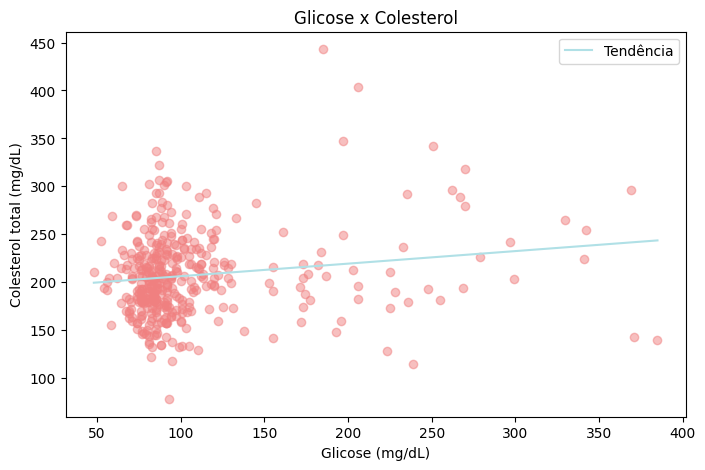

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(dados["stab.glu"], dados["chol"], alpha=0.5, color = "lightcoral")
coef = np.polyfit(dados["stab.glu"], dados["chol"], 1)
x = np.linspace(dados["stab.glu"].min(), dados["stab.glu"].max(), 100)
plt.plot(x, np.polyval(coef, x), color="powderblue", label="Tendência")
plt.xlabel("Glicose (mg/dL)")
plt.ylabel("Colesterol total (mg/dL)")
plt.title("Glicose x Colesterol")
plt.legend()
plt.show()

**Conclusão**: Pacientes com glicose muito elevada apresentam colesterol médio cerca de 18 mg/dL maior que os de glicose normal Apesar da tendência positiva, a correlação é fraca, indicando que a glicose sozinha não é um bom preditor do colesterol. Além disso, correlação não implica causalidade.

- ## **Hipótese 02**: Homens e mulheres apresentam diferenças em glicose, HDL e hemoglobina glicada mesmo quando comparados em faixas de peso semelhantes.

In [171]:
dados = df.dropna(subset=["glyhb", "weight", "gender"]).copy()
dados["faixa_peso"] = pd.qcut(dados["weight"], 3, labels=["Leve", "Médio", "Pesado"])

tabela = dados.groupby(["faixa_peso", "gender"], observed=True)[["stab.glu", "hdl", "glyhb"]].mean().round(2)
print(tabela)

                   stab.glu    hdl  glyhb
faixa_peso gender                        
Leve       female     93.39  57.12   5.07
           male       97.81  58.40   5.15
Médio      female    101.29  49.20   5.30
           male      109.62  47.63   5.76
Pesado     female    116.93  47.86   6.20
           male      127.31  40.80   5.98


In [172]:
indicadores = ["weight", "glyhb", "stab.glu", "hdl", "chol", "ratio"]
print(dados.groupby("gender")[indicadores].mean().round(2))



        weight  glyhb  stab.glu    hdl    chol  ratio
gender                                               
female  174.28   5.49    103.11  51.84  208.36   4.37
male    181.70   5.68    112.51  48.11  206.30   4.75


As faixas de peso (em libras) no dataset ficaram: (Leve 99-159) -  (Médio 160-187) - (Pesado 188 - 325).

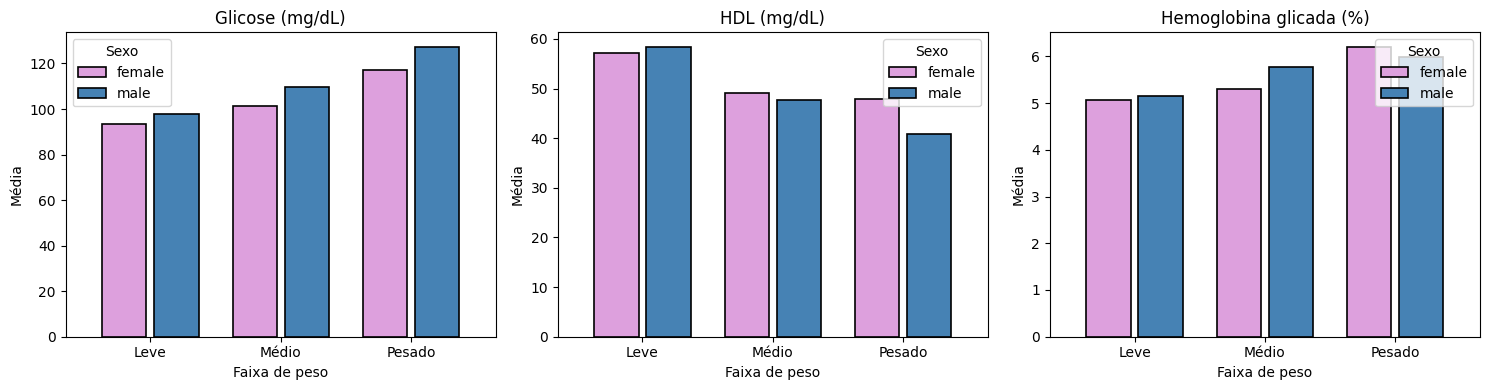

In [173]:
dados["faixa_peso"] = pd.qcut(dados["weight"], 3, labels=["Leve", "Médio", "Pesado"])
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
for eixo, col, nome in zip(eixos, ["stab.glu", "hdl", "glyhb"],
                           ["Glicose (mg/dL)", "HDL (mg/dL)", "Hemoglobina glicada (%)"]):
    dados.groupby(["faixa_peso", "gender"], observed=True)[col].mean().unstack().plot(
        kind="bar", ax=eixo, color=["plum", "steelblue"],
        width=0.8, edgecolor="black", linewidth=1.2)
    for barra in eixo.patches:
        centro = barra.get_x() + barra.get_width() / 2
        nova_largura = barra.get_width() * 0.85
        barra.set_width(nova_largura)
        barra.set_x(centro - nova_largura / 2)
    eixo.set_title(nome)
    eixo.set_xlabel("Faixa de peso")
    eixo.set_ylabel("Média")
    eixo.tick_params(axis="x", rotation=0)
    eixo.legend(title="Sexo")
plt.tight_layout()
plt.show()

**Conclusão**: Mesmo comparando grupos de peso semelhante, os homens apresentam glicose mais alta em todas as faixas e HDL mais baixo nas faixas média e pesada, o que sugere que o peso não é o único fator. Já para a hemoglobina glicada, a diferença entre os sexos não é consistente. As diferenças são pequenas e os grupos têm tamanhos modestos, então seria necessário um teste estatístico para confirmá-las.

- ## **Hipótese 03**: Existe uma correlação positiva entre a pressão sistólica (bp.1s) e a diastólica (bp.1d)?

In [ ]:
dados["faixa_sistolica"] = pd.cut(
    dados["bp.1s"],
    bins=[0, 120, 139, np.inf],
    labels=["Normal (<=120)", "Elevada (121-139)", "Alta (>=140)"]
)
media = dados.groupby("faixa_sistolica", observed=True)["bp.1d"].mean().round(1)
print(media)

faixa_sistolica
Normal (<=120)       72.4
Elevada (121-139)    81.4
Alta (>=140)         91.0
Name: bp.1d, dtype: float64


As faixas (120 e 140 mmHg) seguem valores de referência comuns para a pressão sistólica.

               Correlação entre pressão sistólica e diastólica: 0.60


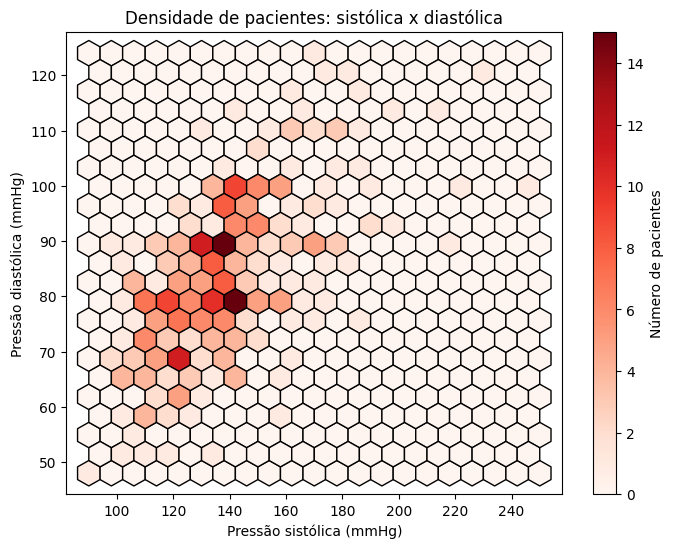

In [ ]:
dados = df[["bp.1s", "bp.1d"]].dropna()
corr = dados["bp.1s"].corr(dados["bp.1d"])
print(f"               Correlação entre pressão sistólica e diastólica: {corr:.2f}")
plt.figure(figsize=(8, 6))
plt.hexbin(dados["bp.1s"], dados["bp.1d"], gridsize=20, cmap="Reds", edgecolor="black")
plt.colorbar(label="Número de pacientes")
plt.xlabel("Pressão sistólica (mmHg)")
plt.ylabel("Pressão diastólica (mmHg)")
plt.title("Densidade de pacientes: sistólica x diastólica")
plt.show()

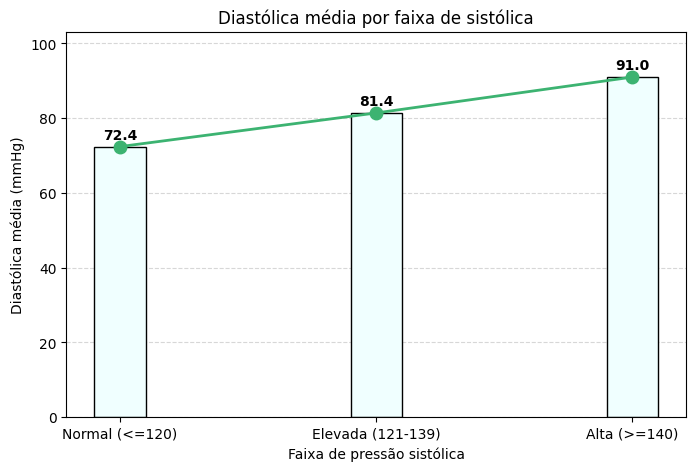

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(media.index, media.values, width=0.20, color="azure",
        edgecolor="black", linewidth=1, zorder=2)

plt.plot(media.index, media.values, color="mediumseagreen", marker="o",
         markersize=9, linewidth=2, zorder=3)

for i, valor in enumerate(media.values):
    plt.text(i, valor + 2, f"{valor}", ha="center", fontweight="bold")

plt.xlabel("Faixa de pressão sistólica")
plt.ylabel("Diastólica média (mmHg)")
plt.title("Diastólica média por faixa de sistólica")
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.ylim(0, media.max() + 12)
plt.show()

**Conclusão**: Existe uma correlação positiva moderada (0,60) entre a pressão sistólica e a diastólica, pacientes com sistólica alta (>=140) têm diastólica média de 91 mmHg. Já os de sistólica normal 72 mmHg. Isso é esperado, pois as duas medidas refletem o mesmo sistema circulatório. A correlação não é perfeita, ou seja, algumas pessoas têm sistólica alta com diastólica normal.

# **MACHINE LEARNING: TREINO E TESTE** 🧠

Alvo:

In [198]:
y = df["Tem Diabetes?"]

X:

In [183]:
X = df.drop(columns=["Tem Diabetes?", "glyhb", "id", "bp.2s", "bp.2d"]) # bp.2s/bp.2d (cerca de 65% de valores nulos)

X["frame"] = X["frame"].fillna("desconhecido") #criando uma categoria para não perder informação

X = pd.get_dummies(X, drop_first=True) # viram numeros

print(f"X: {X.shape[0]} pacientes, {X.shape[1]} variáveis") # viewer

X: 390 pacientes, 19 variáveis


In [246]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size = 0.25,    # 25% para teste
    random_state = 42,   # divisão reproduzível
    stratify=y         # mantém a proporção de diabéticos nos dois grupos
)

print(f"Treino: {len(X_treino)} pacientes ({len(X_treino)/len(X):.0%})") #viewer
print(f"Teste:  {len(X_teste)} pacientes ({len(X_teste)/len(X):.0%})") #viewer

Treino: 292 pacientes (75%)
Teste:  98 pacientes (25%)


Com base em testes feitos em divisões de 1/3, 1/4 e 1/5 (Testes/Treinos), Ramdom Forest de sobressai em relação ao KNN por cerca de 3%-5% acurácia. Resolvi permanecer com o teste de 25% por conta da quantia aproximada de 100 pacientes.

In [247]:
pd.DataFrame({
    "Treino (%)": y_treino.value_counts(normalize=True).mul(100).round(1),
    "Teste (%)":  y_teste.value_counts(normalize=True).mul(100).round(1)
})

,Treino (%),Teste (%)
Tem Diabetes?,,
Não,83.2,83.7
Sim,16.8,16.3


In [248]:
# A mediana é calculada apenas no treino, para o teste não "vazar" informação
medianas = X_treino.median()
X_treino = X_treino.fillna(medianas)
X_teste = X_teste.fillna(medianas)

print("Nulos restantes no treino:", X_treino.isnull().sum().sum())
print("Nulos restantes no teste: ", X_teste.isnull().sum().sum())

Nulos restantes no treino: 0
Nulos restantes no teste:  0


Biblioteca: sklearn

In [249]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# **MACHINE LEARNING: KNN** 🏡

In [250]:
knn = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("modelo", KNeighborsClassifier())
])
busca_knn = GridSearchCV(
    knn,
    {"modelo__n_neighbors": [3, 5, 7, 9, 11, 15],
     "modelo__weights": ["uniform", "distance"]},
    cv=cv, scoring="accuracy"
).fit(X_treino, y_treino)

# **MACHINE LEARNING: RANDOM FOREST 🌲**

In [251]:
rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("modelo", RandomForestClassifier(random_state=42))
])
busca_rf = GridSearchCV(
    rf,
    {"modelo__n_estimators": [100, 200, 300],
     "modelo__max_depth": [None, 5, 10],
     "modelo__min_samples_leaf": [1, 2, 4]},
    cv=cv, scoring="accuracy"
).fit(X_treino, y_treino)

print("Melhores parâmetros KNN:", busca_knn.best_params_)
print("Melhores parâmetros RF: ", busca_rf.best_params_)

Melhores parâmetros KNN: {'modelo__n_neighbors': 5, 'modelo__weights': 'uniform'}
Melhores parâmetros RF:  {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 300}


# **COMPARAÇÃO**

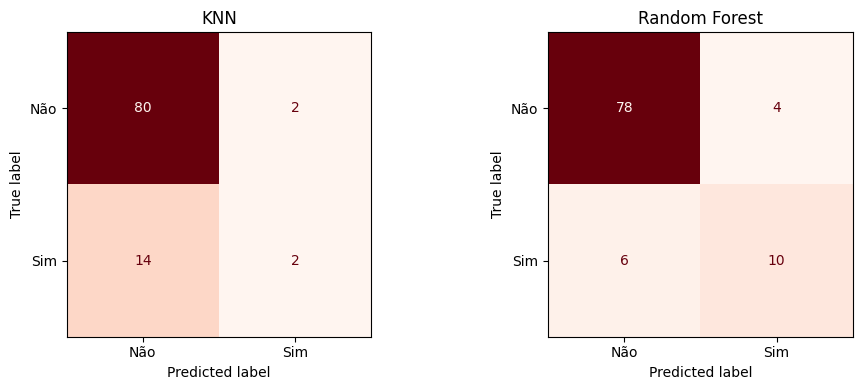

In [252]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
for eixo, (nome, modelo) in zip(eixos, modelos.items()):
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_teste, y_teste, labels=["Não", "Sim"],
        cmap="Reds", ax=eixo, colorbar=False)
    eixo.set_title(nome)
plt.tight_layout()
plt.show()

In [254]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, ConfusionMatrixDisplay)
modelos = {"KNN": busca_knn, "Random Forest": busca_rf}
resultados = {}
for nome, modelo in modelos.items():
    pred = modelo.predict(X_teste)
    resultados[nome] = {
        "Acurácia": accuracy_score(y_teste, pred),
        "Precisão (Sim)": precision_score(y_teste, pred, pos_label="Sim"),
        "Recall (Sim)": recall_score(y_teste, pred, pos_label="Sim"),
        "F1 (Sim)": f1_score(y_teste, pred, pos_label="Sim"),
    }
tabela = pd.DataFrame(resultados).round(3)
print(tabela)

                  KNN  Random Forest
Acurácia        0.857          0.898
Precisão (Sim)  0.667          0.750
Recall (Sim)    0.250          0.562
F1 (Sim)        0.364          0.643


# **Conclusão**

Ambos os modelos superaram os 85% de acurácia com o Random Forest alcançando aproximadamente 90% e KNN com seus aproximados 85%. O Random Forest teve desempenho superior em todas as métricas, e Ele lida melhor com variáveis de escalas e importâncias diferentes e com relações não lineares. Como limitações, o conjunto de teste é pequeno (129 pacientes, 21 diabéticos), então um único paciente classificado diferente muito as métricas. Além disso, o Random Forest ainda deixou 8 diabéticos sem identificar, o que seria muito relevante.

In [256]:
import joblib

melhor_nome = tabela.loc["Acurácia"].idxmax()
melhor_modelo = modelos[melhor_nome].best_estimator_
joblib.dump(melhor_modelo, "melhor_modelo_diabetes.joblib")
print(f"Modelo salvo: {melhor_nome}")

from google.colab import files
files.download("melhor_modelo_diabetes.joblib")

Modelo salvo: Random Forest


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Melhor Modelo Salvo.